In [1]:
import logging
from dotenv import load_dotenv
from evals import Dataset
from evals.metrics import CollectMetrics
import warnings
from huggingface_hub.utils import _http
logger = logging.getLogger(__name__)

logging.getLogger(__name__).setLevel(logging.DEBUG)
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)


warnings.filterwarnings(
    "ignore",
    message=".*UNEXPECTED.*",
    #message = ".*Warning.*",
    category=UserWarning,
    module="transformers.modeling_utils"  
)

load_dotenv()

True

## Fetch results

In [2]:
ds = Dataset("THRD-2021-163881")
cm = CollectMetrics()
eval_res = ds.load_evaluation_results()
all_eval_runs = cm.organize_runs_by_type(eval_res)

In [3]:
coll_res = ds.load_results()
all_collected_res = cm.organize_runs_by_type(coll_res)

In [4]:
deepeval_obs = []
for runs in all_eval_runs.values():
    deepeval_obs.extend(cm.collect_deepeval_metrics(runs))

deepeval_obs[:2], len(deepeval_obs)

([DeepEvalObservation(dataset_name='THRD-2021-163881', eval_run_id='457552b3-48ad-42ea-83d1-295873e28b6c', query_id='82d6385b-3f42-4c89-8df6-82cea426f45a', session_id='fce42233-a542-4489-895a-dcedc50b0820', session=0, session_name='Prosjekt-initialisering', llm_model='google_gemini-2.5-flash', agent_type='baseline_rag', name='Turn 3 in session Prosjekt-initialisering', question_type='factual', correctness=1.0, relevancy=1.0, completeness=1.0, success=True),
  DeepEvalObservation(dataset_name='THRD-2021-163881', eval_run_id='457552b3-48ad-42ea-83d1-295873e28b6c', query_id='4839e2f2-4717-4f33-b04f-be81496b2648', session_id='fce42233-a542-4489-895a-dcedc50b0820', session=0, session_name='Prosjekt-initialisering', llm_model='google_gemini-2.5-flash', agent_type='baseline_rag', name='Turn 4 in session Prosjekt-initialisering', question_type='factual', correctness=1.0, relevancy=1.0, completeness=1.0, success=True)],
 192)

In [5]:
berts = []
for runs in all_eval_runs.values():
    berts.extend(cm.collect_berts(runs))

berts[:2], len(berts)

([ReferenceObservation(dataset_name='THRD-2021-163881', eval_run_id='457552b3-48ad-42ea-83d1-295873e28b6c', query_id='82d6385b-3f42-4c89-8df6-82cea426f45a', session_id='fce42233-a542-4489-895a-dcedc50b0820', session=0, session_name='Prosjekt-initialisering', llm_model='google_gemini-2.5-flash', agent_type='baseline_rag', name=None, bert_precision=0.6293909549713135, bert_recall=0.7602494955062866, bert_f1=0.6886589527130127, s_bert_similarity=0.9174683202849897),
  ReferenceObservation(dataset_name='THRD-2021-163881', eval_run_id='457552b3-48ad-42ea-83d1-295873e28b6c', query_id='4839e2f2-4717-4f33-b04f-be81496b2648', session_id='fce42233-a542-4489-895a-dcedc50b0820', session=0, session_name='Prosjekt-initialisering', llm_model='google_gemini-2.5-flash', agent_type='baseline_rag', name=None, bert_precision=0.6104273200035095, bert_recall=0.7710434198379517, bert_f1=0.6813983917236328, s_bert_similarity=0.9056372964456839)],
 192)

In [6]:
gathered_res = ds.load_results()
resource_obs = cm.collect_resource_metrics(list(gathered_res.values()))

resource_obs[:2], len(resource_obs)

([ResourceObservation(starttime=datetime.datetime(2026, 3, 28, 17, 6, 55, 701454), endtime=datetime.datetime(2026, 3, 28, 17, 7, 8, 477987), duration_seconds=12.776533, input_tokens=12089, output_tokens=822, total_tokens=12911, llm_calls=2, dataset_name='THRD-2021-163881', eval_run_id='457552b3-48ad-42ea-83d1-295873e28b6c', query_id='f3f226bb-eb5c-4b87-8d96-dfa425614f42', session_id='fce42233-a542-4489-895a-dcedc50b0820', session=0, session_name='Prosjekt-initialisering', llm_model='google_gemini-2.5-flash', agent_type='baseline_rag'),
  ResourceObservation(starttime=datetime.datetime(2026, 3, 28, 17, 7, 8, 478135), endtime=datetime.datetime(2026, 3, 28, 17, 7, 20, 338720), duration_seconds=11.860585, input_tokens=9560, output_tokens=2504, total_tokens=12064, llm_calls=1, dataset_name='THRD-2021-163881', eval_run_id='457552b3-48ad-42ea-83d1-295873e28b6c', query_id='070f570b-f9d0-454f-90ca-84f66ede1a31', session_id='fce42233-a542-4489-895a-dcedc50b0820', session=0, session_name='Prosjek

## EDA
### Exploratory data analysis

In [7]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from plotly import subplots
import pandas as pd

In [8]:
df_de = pd.DataFrame([dp.model_dump() for dp in deepeval_obs])
df_brt = pd.DataFrame([bert.model_dump() for bert in berts])
df_rm = pd.DataFrame([rm.model_dump() for rm in resource_obs])
drop = ["eval_run_id", 
        "name",
        #"query_id", "session_id", 
        ]
on = ["llm_model", "dataset_name", 
        "query_id", "session_id", "agent_type",
        "session", "session_name"]

df = pd.merge(df_de.drop(columns=drop, errors = "ignore"), df_rm.drop(columns=drop, errors = "ignore"), on = on,)
                                                                                                              
df = pd.merge(df, df_brt.drop(columns=drop, errors = "ignore"), on = on)

In [9]:
df.head()

,dataset_name,query_id,session_id,session,session_name,llm_model,agent_type,question_type,correctness,relevancy,...,endtime,duration_seconds,input_tokens,output_tokens,total_tokens,llm_calls,bert_precision,bert_recall,bert_f1,s_bert_similarity
0,THRD-2021-163881,82d6385b-3f42-4c89-8df6-82cea426f45a,fce42233-a542-4489-895a-dcedc50b0820,0,Prosjekt-initialisering,google_gemini-2.5-flash,baseline_rag,factual,1.0,1.0,...,2026-03-28 17:07:42.745544,12.101114,35162,1063,36225,2,0.629391,0.760249,0.688659,0.917468
1,THRD-2021-163881,4839e2f2-4717-4f33-b04f-be81496b2648,fce42233-a542-4489-895a-dcedc50b0820,0,Prosjekt-initialisering,google_gemini-2.5-flash,baseline_rag,factual,1.0,1.0,...,2026-03-28 17:07:47.972007,5.226263,20751,753,21504,1,0.610427,0.771043,0.681398,0.905637
2,THRD-2021-163881,070f570b-f9d0-454f-90ca-84f66ede1a31,fce42233-a542-4489-895a-dcedc50b0820,0,Prosjekt-initialisering,google_gemini-2.5-flash,baseline_rag,factual,0.6,1.0,...,2026-03-28 17:07:20.338720,11.860585,9560,2504,12064,1,0.659326,0.743674,0.698964,0.938199
3,THRD-2021-163881,335b247f-0a2b-4eef-85f8-5cc0e2c6a2e2,fce42233-a542-4489-895a-dcedc50b0820,0,Prosjekt-initialisering,google_gemini-2.5-flash,baseline_rag,factual,0.6,1.0,...,2026-03-28 17:07:30.644227,10.305444,24952,671,25623,2,0.621907,0.748193,0.679230,0.939552
4,THRD-2021-163881,f3f226bb-eb5c-4b87-8d96-dfa425614f42,fce42233-a542-4489-895a-dcedc50b0820,0,Prosjekt-initialisering,google_gemini-2.5-flash,baseline_rag,summary,0.8,1.0,...,2026-03-28 17:07:08.477987,12.776533,12089,822,12911,2,0.683211,0.747082,0.713721,0.955617


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   dataset_name       59 non-null     object        
 1   query_id           59 non-null     object        
 2   session_id         59 non-null     object        
 3   session            59 non-null     int64         
 4   session_name       59 non-null     object        
 5   llm_model          59 non-null     object        
 6   agent_type         59 non-null     object        
 7   correctness        59 non-null     float64       
 8   relevancy          59 non-null     float64       
 9   completeness       59 non-null     float64       
 10  success            59 non-null     bool          
 11  starttime          59 non-null     datetime64[ns]
 12  endtime            59 non-null     datetime64[ns]
 13  duration_seconds   59 non-null     float64       
 14  input_tokens

In [10]:
df.loc[df["llm_model"] == "qwen_Qwen/Qwen3-Next-80B-A3B-Instruct" , "llm_model"] = "Qwen3-Next-80B-A3B-Instruct"
df.loc[df["llm_model"] == "qwen_Qwen/Qwen3.5-397B-A17B" , "llm_model"] = "Qwen3.5-397B-A17B"
df.loc[df["llm_model"] == "zai_zai-org/GLM-5" , "llm_model"] = "GLM-5"
df.loc[df["llm_model"] == "google_gemini-2.5-flash" , "llm_model"] = "gemini-2.5-flash"

models_to_keep = ["Qwen3.5-397B-A17B", "GLM-5", "gemini-2.5-flash"]
df = df[df["llm_model"].isin(models_to_keep)]
df["llm_model"].value_counts()

llm_model
gemini-2.5-flash    192
Name: count, dtype: int64

### Deep Eval metrics
Correctness, relevancy & completeness

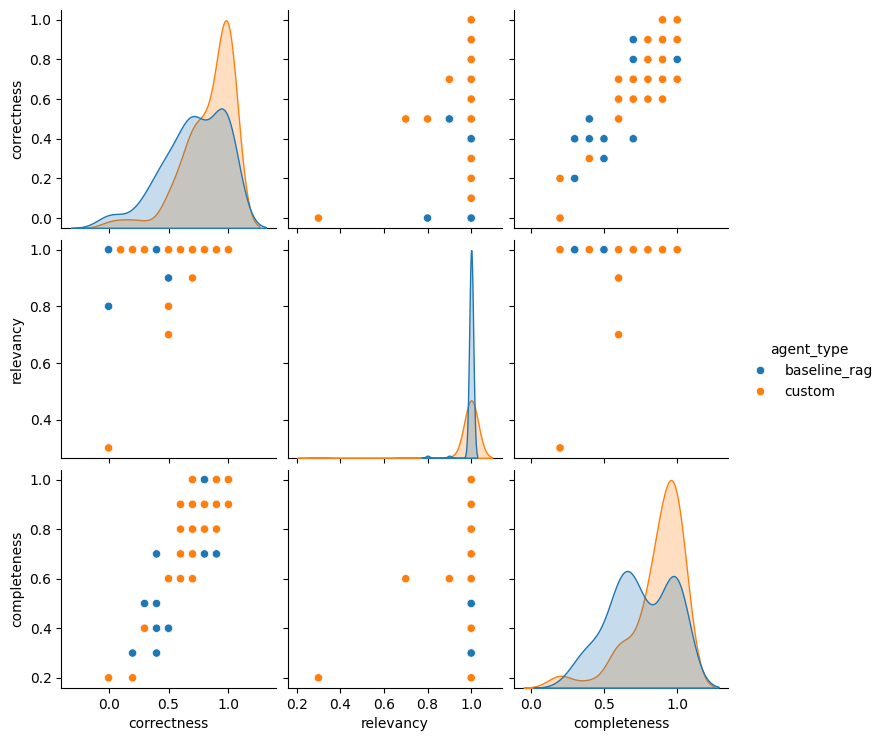

In [11]:
sns.pairplot(df[["correctness", "relevancy", "completeness", "llm_model", "agent_type"]], hue = "agent_type")

<Axes: xlabel='success', ylabel='Count'>

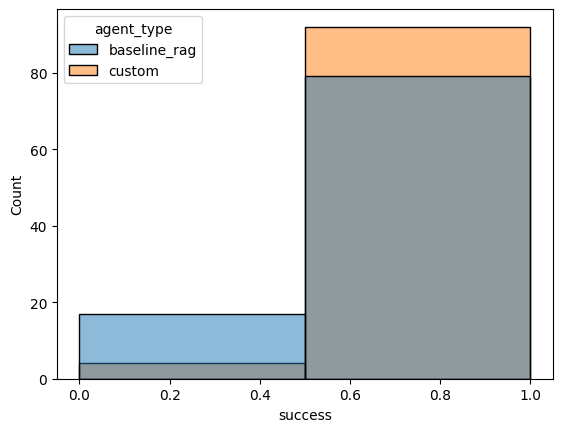

In [13]:
sns.histplot(df, x = "success", hue = "agent_type", bins = 2)

### Bert metrics
S-bert & Bert score

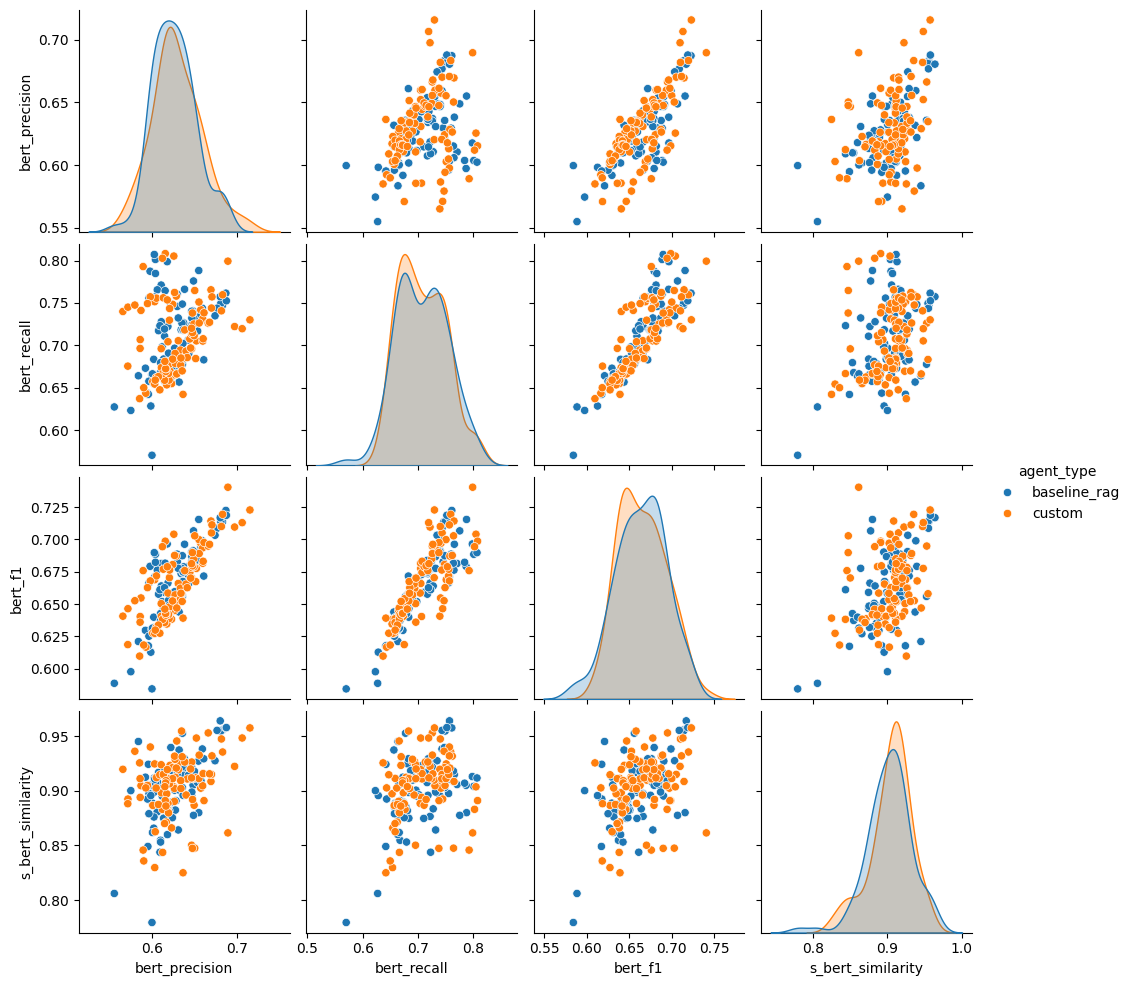

In [14]:
sns.pairplot(df[["bert_precision", "bert_recall", "bert_f1", "s_bert_similarity","llm_model", "agent_type"]], hue = "agent_type")

### Resource metrics
Token & time usage

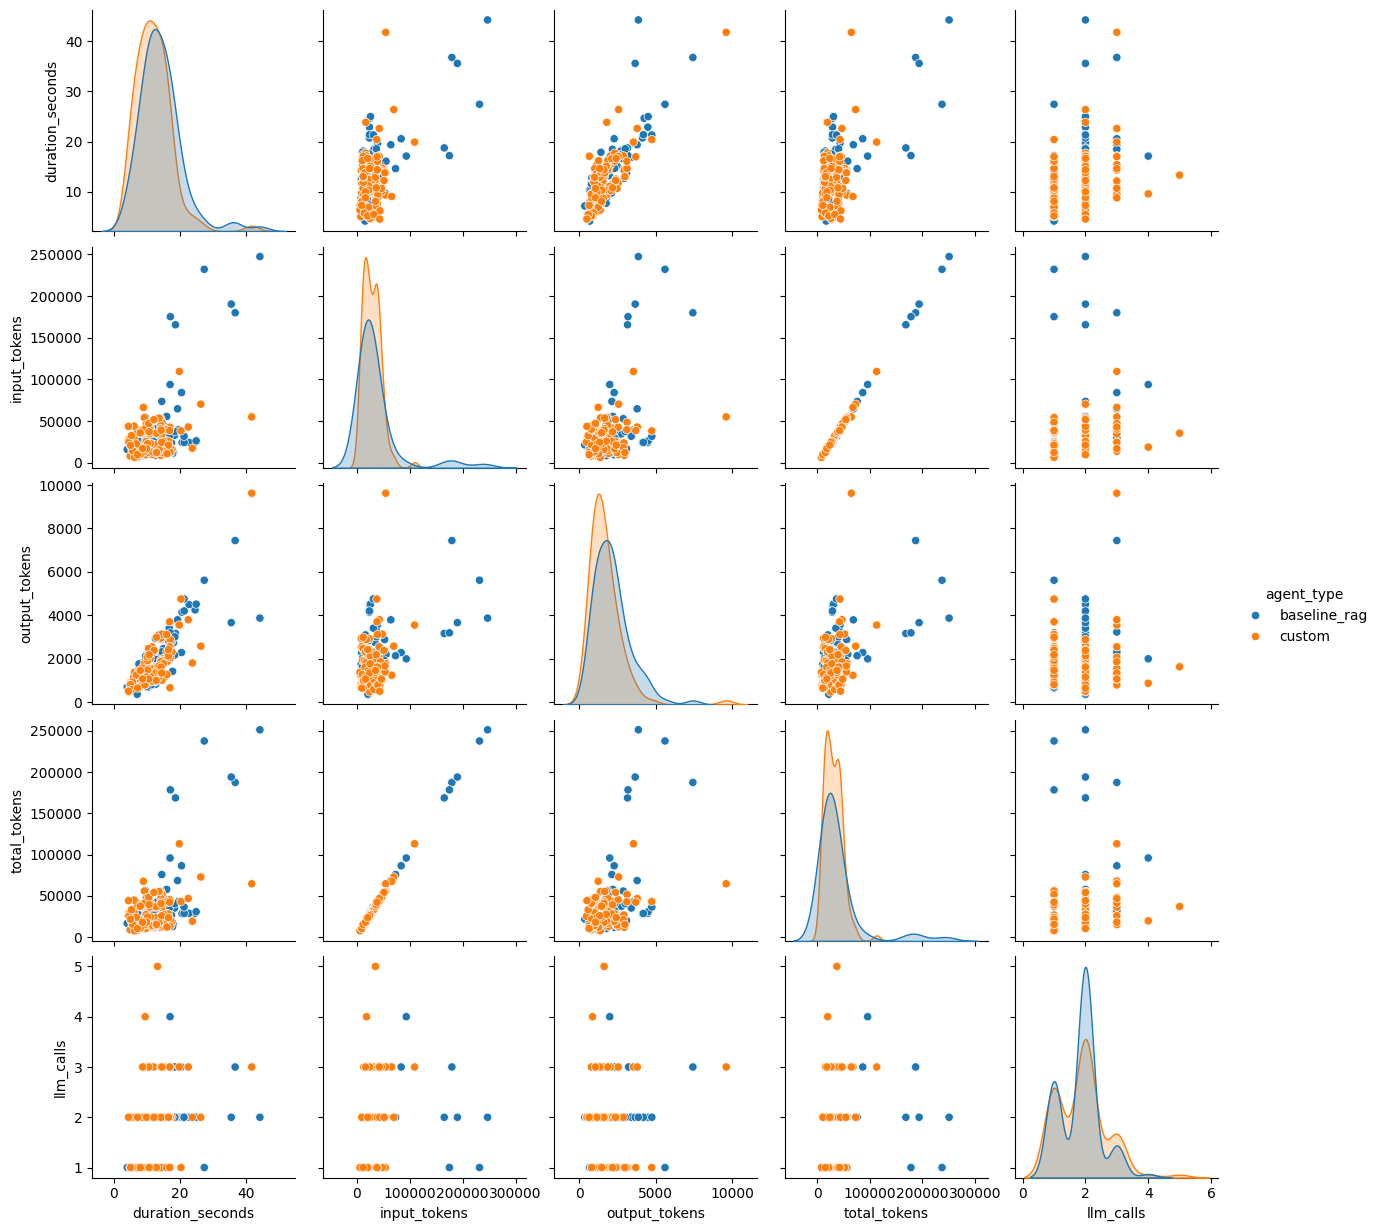

In [15]:
sns.pairplot(df[["duration_seconds", "input_tokens", "output_tokens", "total_tokens" , "llm_calls", "llm_model", "agent_type"]], hue = "agent_type")

### Combined analysis

<Axes: xlabel='duration_seconds', ylabel='correctness'>

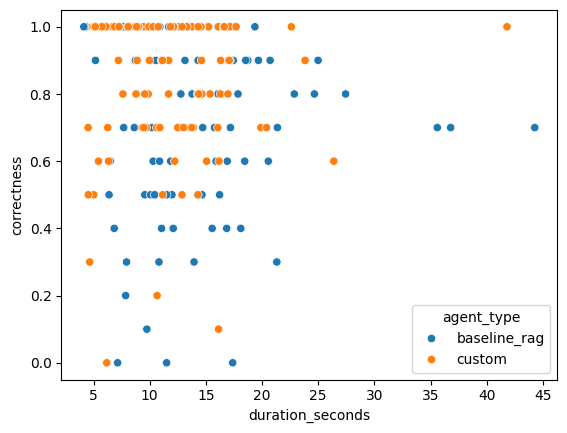

In [16]:
import seaborn as sns

sns.scatterplot(df, x = "duration_seconds", y = "correctness", hue = "agent_type")

In [17]:
dfg = df.groupby(by = ["agent_type", "llm_model"],).agg({"correctness" : "mean", 
                                                         "relevancy" : "mean",
                                                         "completeness" : "mean",
                                                         "bert_f1" : "mean",
                                                         "duration_seconds" : "mean",
                                                         "total_tokens" : "mean"})

In [18]:
dfg

,,correctness,relevancy,completeness,bert_f1,duration_seconds,total_tokens
agent_type,llm_model,,,,,,
baseline_rag,gemini-2.5-flash,0.709375,0.996875,0.748333,0.663675,14.246360,38913.000000
custom,gemini-2.5-flash,0.832292,0.986458,0.860000,0.665451,12.019507,30670.697917


In [19]:
dfs = df.groupby(by = ["agent_type", "llm_model", "session",],).agg({"correctness" : "mean", 
                                                         "relevancy" : "mean",
                                                         "completeness" : "mean",
                                                         "bert_f1" : "mean",
                                                         "duration_seconds" : "mean",
                                                         "total_tokens" : "mean"})

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

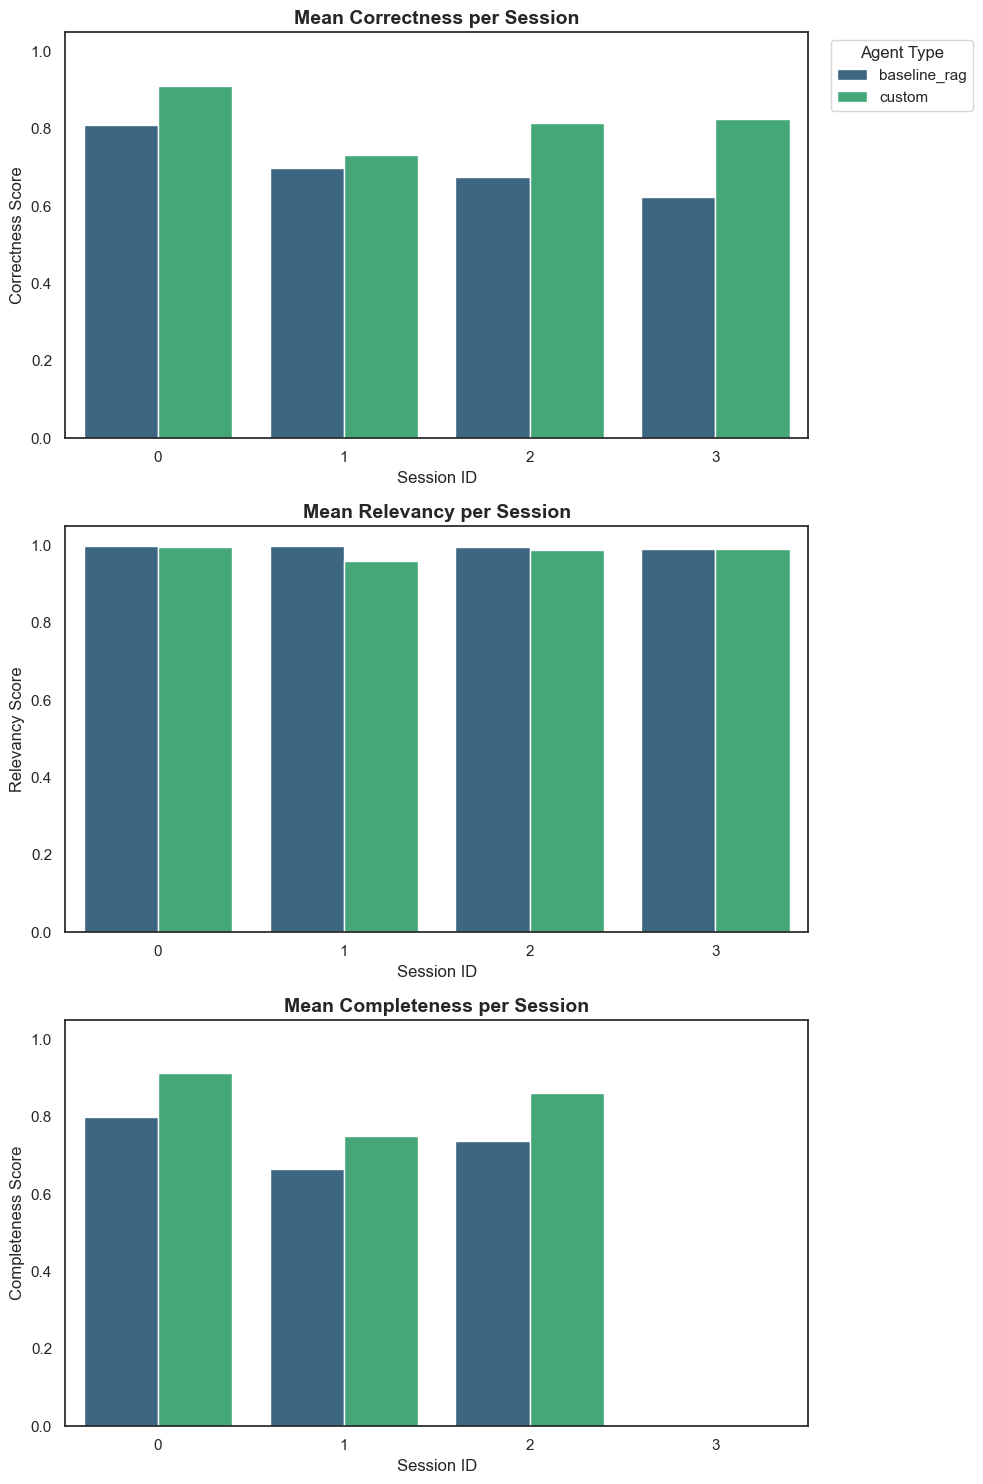

''

In [20]:
sns.set_theme(style="white")
metrics = ["correctness", "relevancy", "completeness"]

fig, axes = plt.subplots(nrows=len(metrics), ncols=1, figsize=(10, 15), sharey=True)

for i, metric in enumerate(metrics):
    sns.barplot(
        data=dfs,
        x="session",
        y=metric,
        hue="agent_type",
        ax=axes[i],
        palette="viridis",
        errorbar=None
    )
    
    axes[i].set_title(f"Mean {metric.capitalize()} per Session", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Session ID", fontsize=12)
    axes[i].set_ylabel(f"{metric.capitalize()} Score", fontsize=12)
    
    if i != 0:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(title="Agent Type", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()
;

<Axes: xlabel='session', ylabel='correctness'>

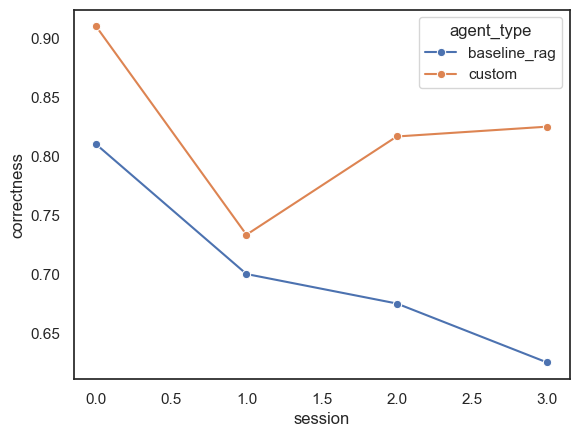

In [ ]:
sns.set_theme(style="white")
plot_df = dfs.reset_index().sort_values("session")
sns.lineplot(data=plot_df, x="session", y="correctness", hue="agent_type", marker="o")

## Statistical Modeling

In [21]:
import numpy as np
from scipy import stats 

from evals.models import DeepEvalObservation

In [32]:
class StatisticalMetrics:
    def __init__(self, significance_level: float = 0.05):
        self.significance_level = significance_level

    def check_normality(self, values : list[float]):
            result = stats.shapiro(values)
            status = "✅" if result.pvalue > self.significance_level else "❌"
            print(f"{status} : {result}")

    def t_test(self, custom_eval: list[float] | np.ndarray, comparison_eval: list[float] | np.ndarray):
        t_stat, p = stats.ttest_ind(custom_eval, comparison_eval, equal_var=False, alternative='greater')
        print(f"Custom vs. Comparison: t={t_stat:.2f}, p={p:.4f}")
        if p < self.significance_level:
            print("✅ Custom beats Comparison (p<0.05).")
        else:
            print("❌ No significant difference (p>=0.05).")

def filter_evals(agent_type: str, metric: str = "correctness", llm_model: list[str] | None = None):
    if llm_model is not None:
        return df.loc[(df["agent_type"] == agent_type) & (df["llm_model"].isin(llm_model)), [metric]].values.flatten()  
    return df.loc[df["agent_type"] == agent_type, [metric]].values.flatten()

In [26]:
from collections import Counter
count = Counter(obs.agent_type for obs in deepeval_obs)
if count.get("custom") != count.get("baseline") or count.get("custom") != count.get("baseline_rag"):
    print("⚠️ Warning: Unbalanced dataset! counts : ", count)

⚠️ Warning: Unbalanced dataset! counts :  Counter({'baseline_rag': 96, 'custom': 96})


### One-sided Hypothesis Tests

**For quality/performance metrics** (correctness, relevancy, completeness, passrate):

$$
H_0: \mu_{\text{custom}} \leq \mu_{\text{baseline}} \qquad H_1: \mu_{\text{custom}} > \mu_{\text{baseline}}
$$

(and analogously vs. baseline+RAG)

**For cost/efficiency metrics** (token usage, inference time):

$$
H_0: \mu_{\text{custom}} \geq \mu_{\text{baseline}} \qquad H_1: \mu_{\text{custom}} < \mu_{\text{baseline}}
$$

(and analogously vs. baseline+RAG)

**Notation:**

- $\mu_{\text{custom}}$ = population mean for the custom agent  
- $\mu_{\text{baseline}}$ = population mean for the baseline agent  
- $\mu_{\text{baseline+RAG}}$ = population mean for baseline with RAG  

All tests are one-tailed / one-sided.

In [33]:
sm = StatisticalMetrics()
sm.check_normality(filter_evals("custom", "correctness"))
sm.t_test(custom_eval=filter_evals("custom", "correctness", 
                                    #llm_model = ["google_gemini-2.5-flash"],
                                    ), 
        comparison_eval=filter_evals("baseline_rag", "correctness", 
                                        #llm_model=["google_gemini-2.5-flash"],
                                        ))
                       

❌ : ShapiroResult(statistic=np.float64(0.7806254364953608), pvalue=np.float64(1.1786176289568483e-10))
Custom vs. Comparison: t=3.58, p=0.0002
✅ Custom beats Comparison (p<0.05).
